In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, roc_curve,
    ConfusionMatrixDisplay
)

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB

from sklearn.decomposition import PCA
import joblib


In [2]:
df = pd.read_csv("D:/Machine Learning datasets/Classification/Student_Performance_Teaching_Effectiveness.csv")

print(df.head())
print(df.info())
print(df.describe())


  Student_ID  Age  Gender  Attendance_Percentage  Assignments_Completed  \
0      S0001   24  Female                  75.95                      2   
1      S0002   21  Female                  73.96                      3   
2      S0003   22    Male                  51.28                      6   
3      S0004   24  Female                  67.06                      2   
4      S0005   20  Female                  69.01                      8   

   Class_Participation  Midterm_Grade  Final_Grade  Study_Hours_per_Week  \
0                 7.94          52.36        33.88                     9   
1                 8.84          28.23        40.51                     2   
2                 3.45          29.81        23.90                    19   
3                 4.62          27.78        62.89                     9   
4                 4.15          77.15        64.04                    17   

   Projects_Submitted  Teaching_Clarity  Teaching_Helpfulness  \
0                   1      

In [3]:
df["Performance"] = (df["Final_Grade"] >= df["Final_Grade"].median()).astype(int)
df.drop(columns=["Final_Grade"], inplace=True)


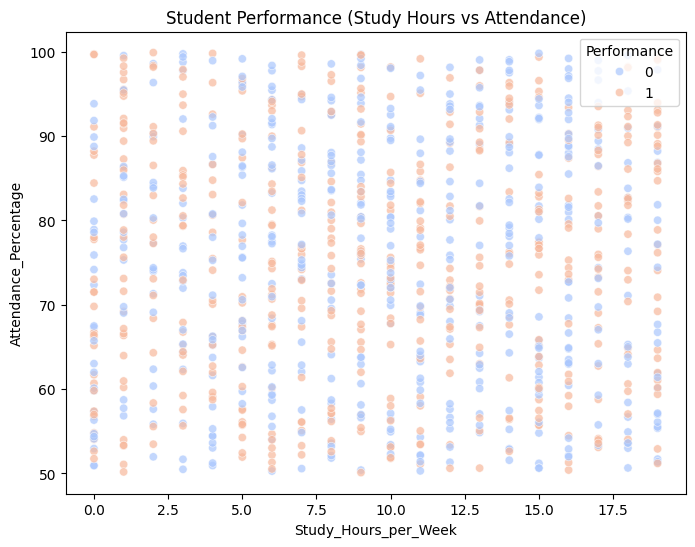

In [4]:
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df,
    x="Study_Hours_per_Week",
    y="Attendance_Percentage",
    hue="Performance",
    palette="coolwarm",
    alpha=0.7
)
plt.title("Student Performance (Study Hours vs Attendance)")
plt.show()


In [5]:
def handle_outliers_iqr(data, cols):
    for col in cols:
        Q1 = data[col].quantile(0.25)
        Q3 = data[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        data[col] = np.where(
            data[col] < lower, lower,
            np.where(data[col] > upper, upper, data[col])
        )
    return data

num_cols = df.select_dtypes(include=["int64","float64"]).columns.drop("Performance")
df = handle_outliers_iqr(df, num_cols)


In [6]:
num_imputer = SimpleImputer(strategy="median")
cat_imputer = SimpleImputer(strategy="most_frequent")

num_cols = df.select_dtypes(include=["int64","float64"]).columns
cat_cols = df.select_dtypes(include=["object"]).columns

df[num_cols] = num_imputer.fit_transform(df[num_cols])
df[cat_cols] = cat_imputer.fit_transform(df[cat_cols])

for col in cat_cols:
    df[col] = LabelEncoder().fit_transform(df[col])


In [7]:
X = df.drop("Performance", axis=1)
y = df["Performance"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


In [8]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [9]:
print(pd.DataFrame(X_train_scaled).describe())


                 0             1             2             3             4   \
count  8.000000e+02  8.000000e+02  8.000000e+02  8.000000e+02  8.000000e+02   
mean  -7.327472e-17  4.907186e-16 -2.275957e-17  3.641532e-16  8.659740e-17   
std    1.000626e+00  1.000626e+00  1.000626e+00  1.000626e+00  1.000626e+00   
min   -1.714657e+00 -1.512663e+00 -9.760746e-01 -1.733817e+00 -1.585202e+00   
25%   -8.598335e-01 -1.080628e+00 -9.760746e-01 -8.473125e-01 -9.558414e-01   
50%   -1.886760e-02 -2.165576e-01  5.520265e-01  2.250505e-02 -1.180051e-02   
75%    8.705989e-01  1.079548e+00  5.520265e-01  8.659013e-01  9.322404e-01   
max    1.746208e+00  1.511583e+00  2.080128e+00  1.731547e+00  1.561601e+00   

                 5             6             7             8             9   \
count  8.000000e+02  8.000000e+02  8.000000e+02  8.000000e+02  8.000000e+02   
mean  -6.328271e-17 -1.182388e-16  6.661338e-17  4.440892e-17 -4.352074e-16   
std    1.000626e+00  1.000626e+00  1.000626e+00  1.

In [10]:
models = {
    "Decision Tree": DecisionTreeClassifier(max_depth=5),
    "Random Forest": RandomForestClassifier(n_estimators=100),
    "Logistic Regression": LogisticRegression(max_iter=3000),
    "KNN": KNeighborsClassifier(n_neighbors=7),
    "SVM Linear": SVC(kernel="linear", probability=True),
    "Naive Bayes": GaussianNB(),
    "SVM Poly d=2": SVC(kernel="poly", degree=2, probability=True),
    "SVM Poly d=3": SVC(kernel="poly", degree=3, probability=True)
}


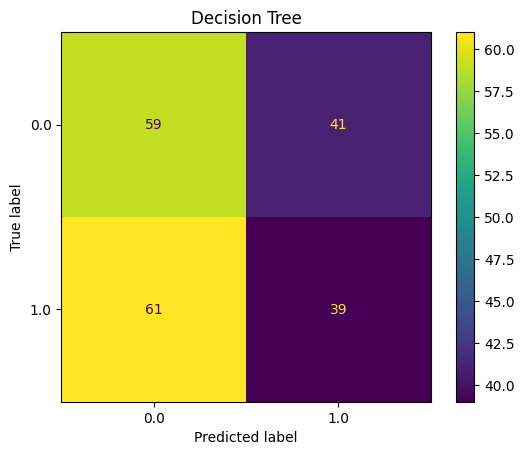

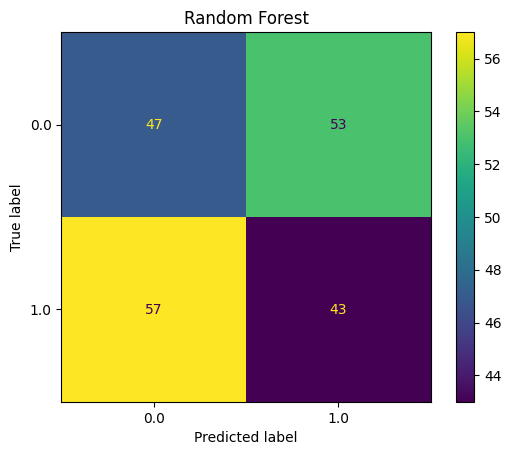

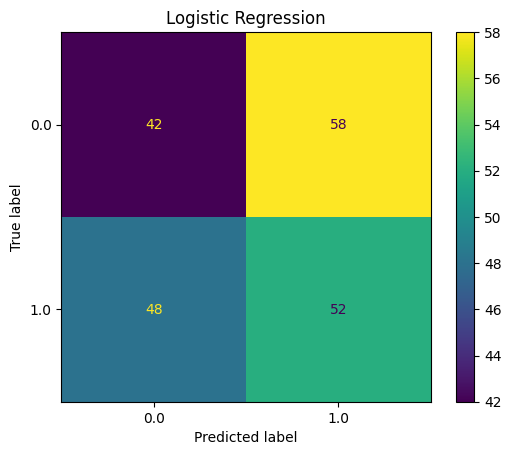

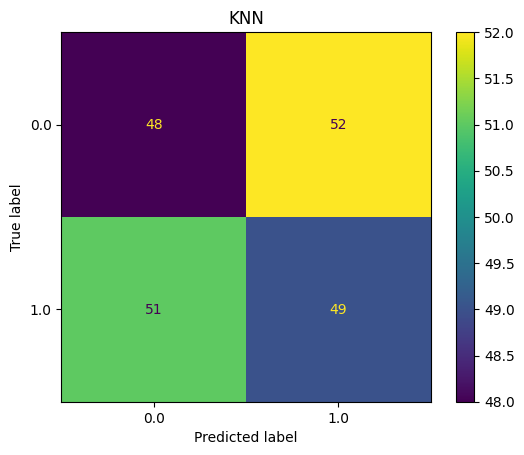

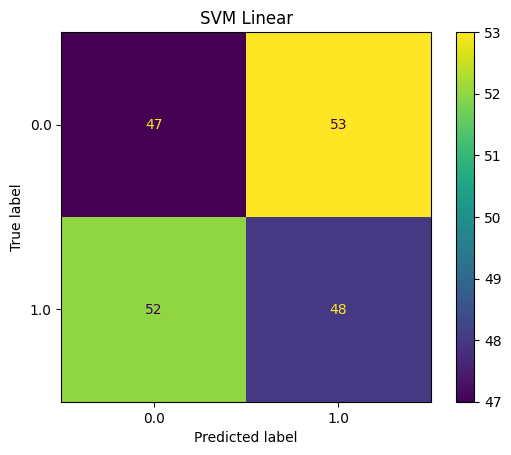

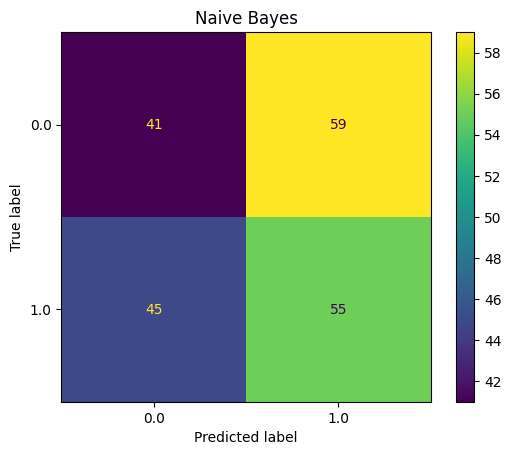

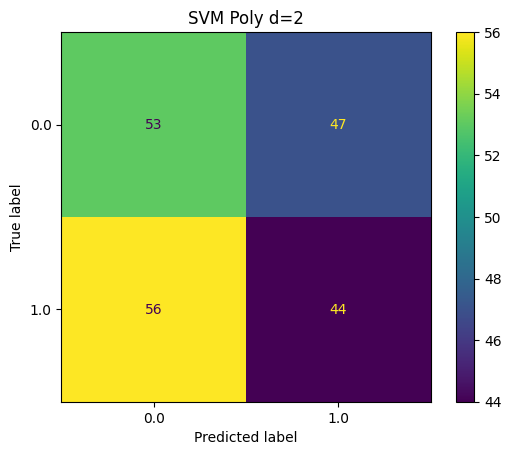

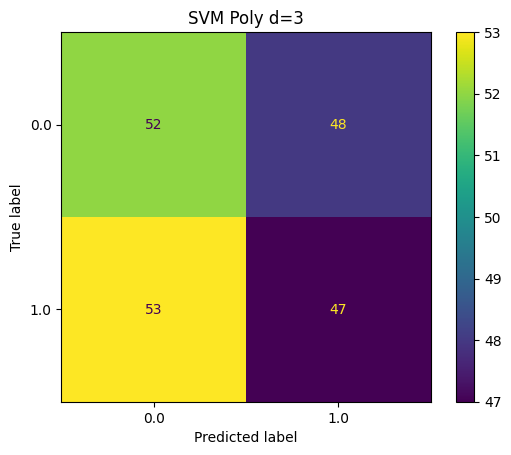

                 Model  Accuracy  Precision  Recall  F1 Score  ROC-AUC
0        Decision Tree     0.490   0.487500    0.39  0.433333   0.4533
1        Random Forest     0.450   0.447917    0.43  0.438776   0.4610
2  Logistic Regression     0.470   0.472727    0.52  0.495238   0.4226
3                  KNN     0.485   0.485149    0.49  0.487562   0.5045
4           SVM Linear     0.475   0.475248    0.48  0.477612   0.4153
5          Naive Bayes     0.480   0.482456    0.55  0.514019   0.4286
6         SVM Poly d=2     0.485   0.483516    0.44  0.460733   0.5348
7         SVM Poly d=3     0.495   0.494737    0.47  0.482051   0.4888


In [11]:
results = []
roc_data = {}

def evaluate(model, name):
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    y_prob = model.predict_proba(X_test_scaled)[:,1]

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_prob)
    })

    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_data[name] = (fpr, tpr)

    ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
    plt.title(name)
    plt.show()

for name, model in models.items():
    evaluate(model, name)

results_df = pd.DataFrame(results)
print(results_df)


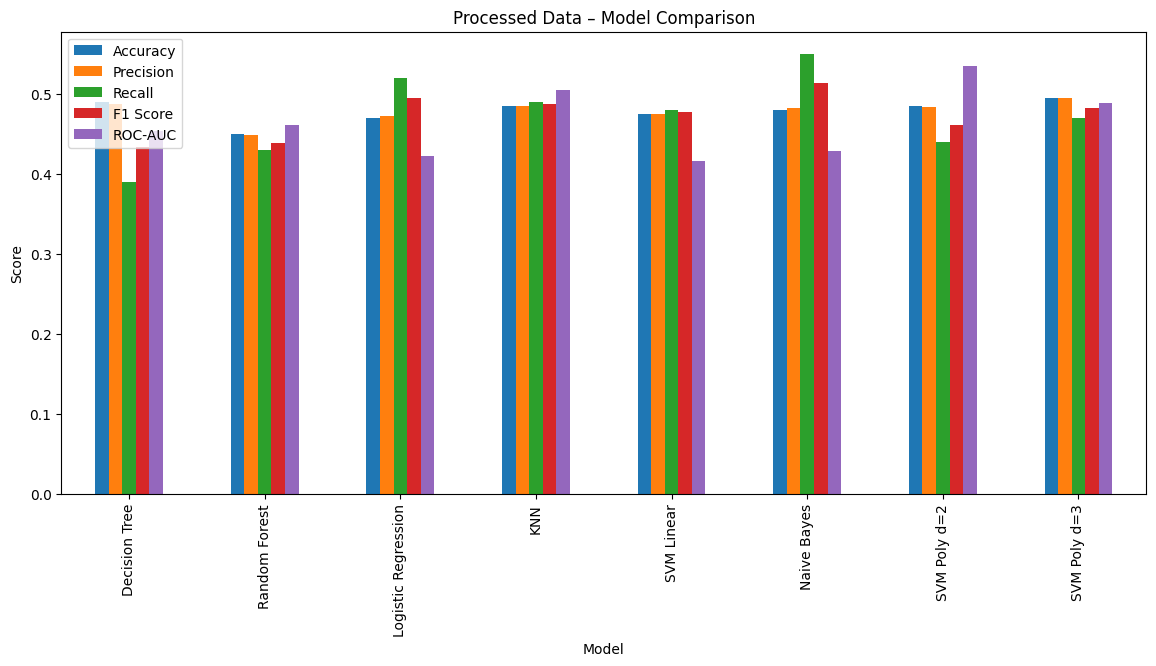

In [12]:
results_df.set_index("Model").plot(kind="bar", figsize=(14,6))
plt.title("Processed Data – Model Comparison")
plt.ylabel("Score")
plt.show()


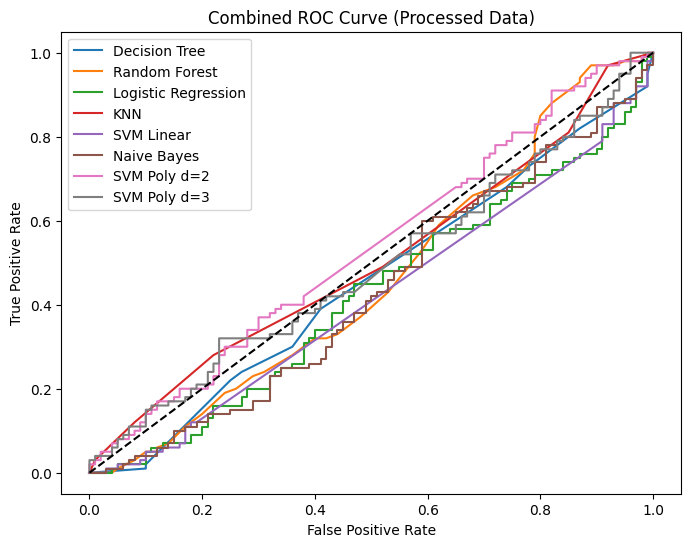

In [13]:
plt.figure(figsize=(8,6))
for name, (fpr, tpr) in roc_data.items():
    plt.plot(fpr, tpr, label=name)

plt.plot([0,1], [0,1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Combined ROC Curve (Processed Data)")
plt.legend()
plt.show()


In [14]:
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    train_acc = accuracy_score(y_train, model.predict(X_train_scaled))
    test_acc = accuracy_score(y_test, model.predict(X_test_scaled))
    print(f"{name} → Train: {train_acc:.3f}, Test: {test_acc:.3f}")


Decision Tree → Train: 0.634, Test: 0.500
Random Forest → Train: 1.000, Test: 0.425
Logistic Regression → Train: 0.569, Test: 0.470
KNN → Train: 0.662, Test: 0.485
SVM Linear → Train: 0.569, Test: 0.475
Naive Bayes → Train: 0.564, Test: 0.480
SVM Poly d=2 → Train: 0.629, Test: 0.485
SVM Poly d=3 → Train: 0.825, Test: 0.495


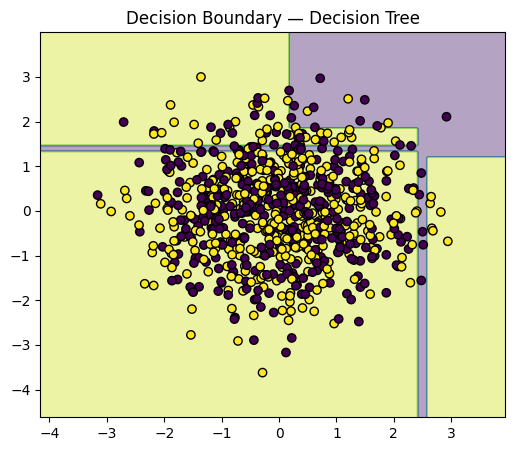

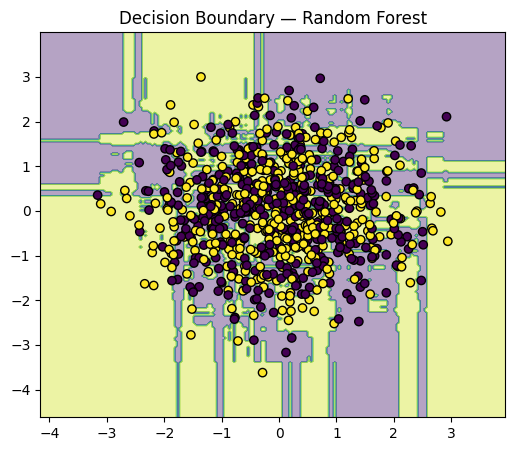

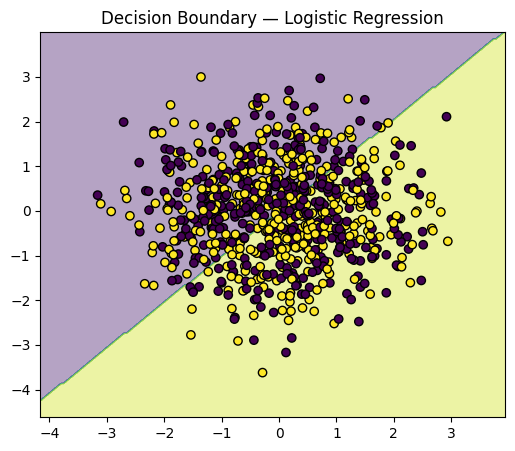

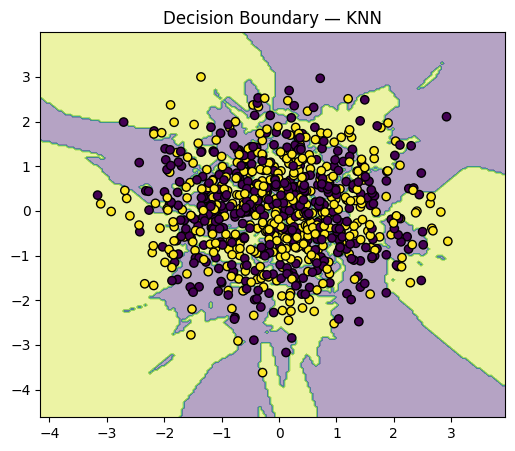

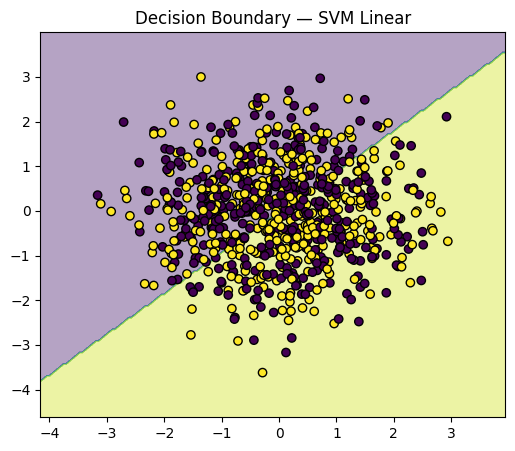

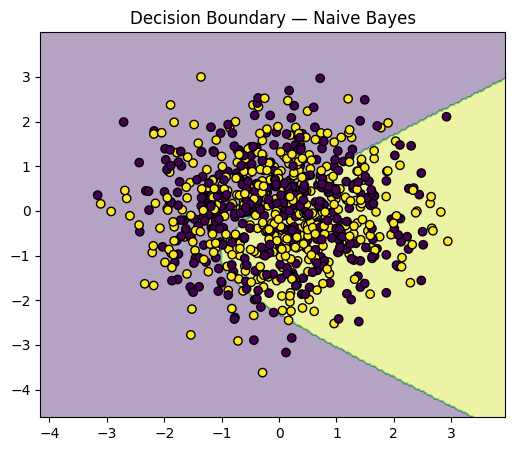

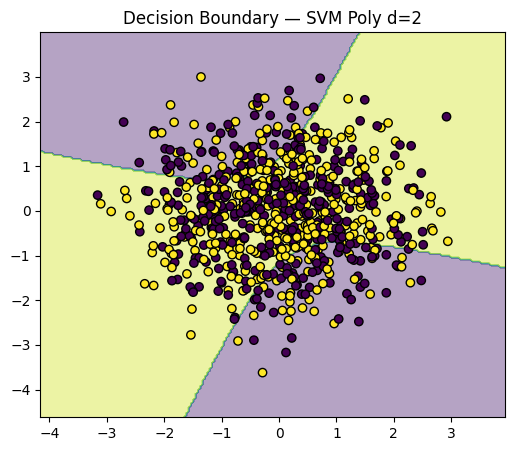

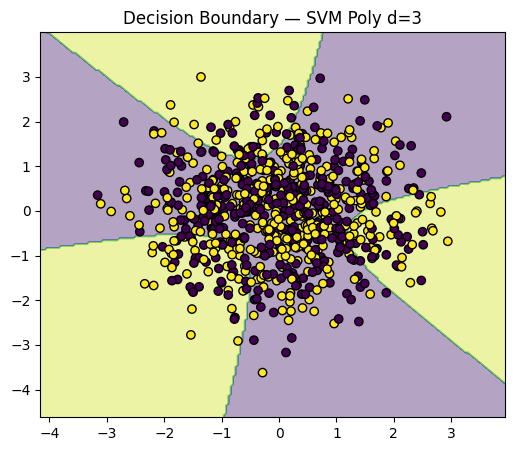

In [15]:
pca = PCA(n_components=2)
X_vis = pca.fit_transform(X_train_scaled)
y_vis = y_train.values

xx, yy = np.meshgrid(
    np.linspace(X_vis[:,0].min()-1, X_vis[:,0].max()+1, 200),
    np.linspace(X_vis[:,1].min()-1, X_vis[:,1].max()+1, 200)
)

for name, model in models.items():
    model.fit(X_vis, y_vis)
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.figure(figsize=(6,5))
    plt.contourf(xx, yy, Z, alpha=0.4)
    plt.scatter(X_vis[:,0], X_vis[:,1], c=y_vis, edgecolor="k")
    plt.title(f"Decision Boundary — {name}")
    plt.show()


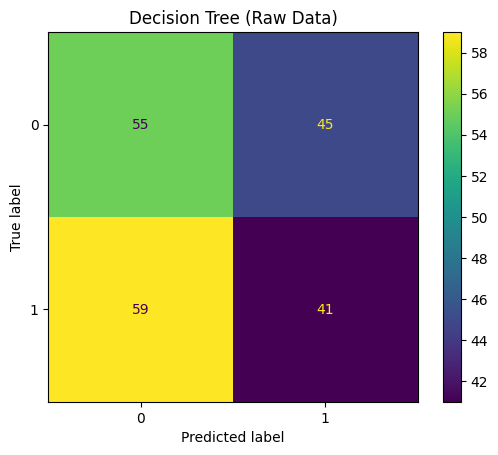

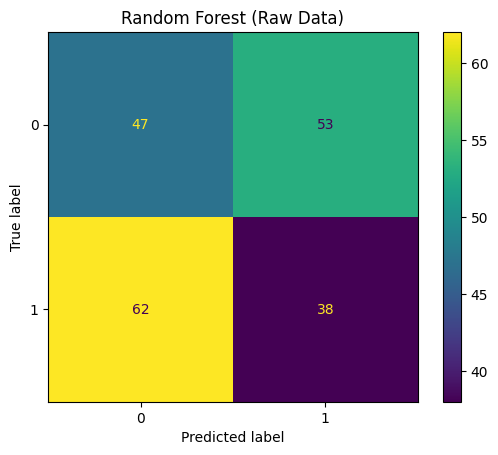

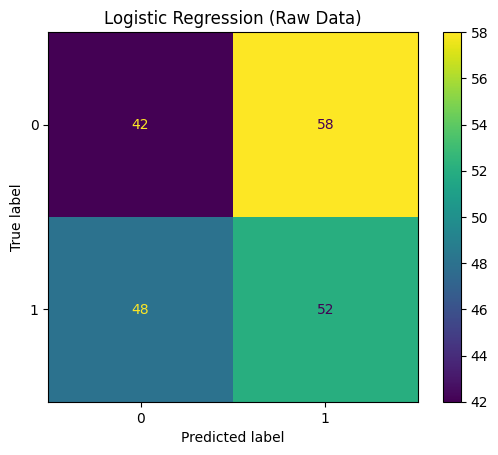

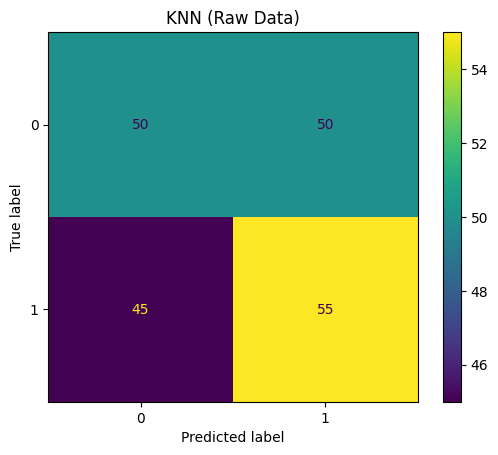

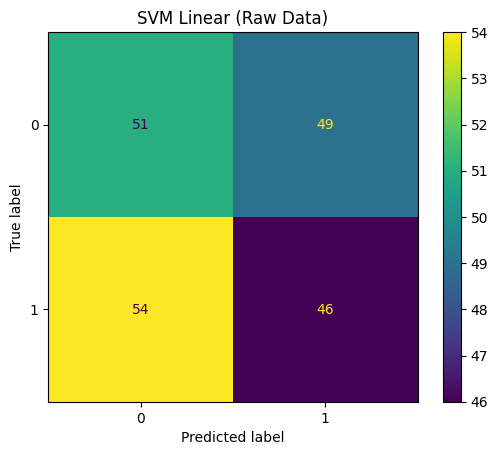

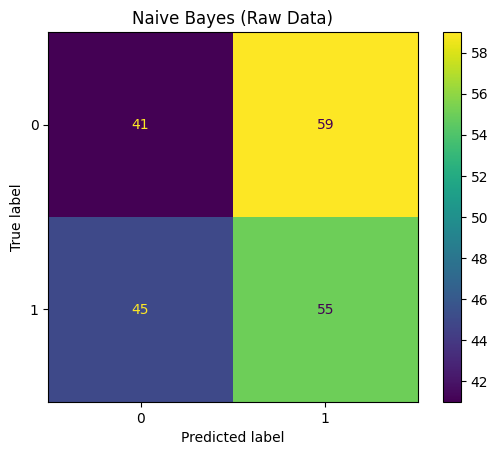

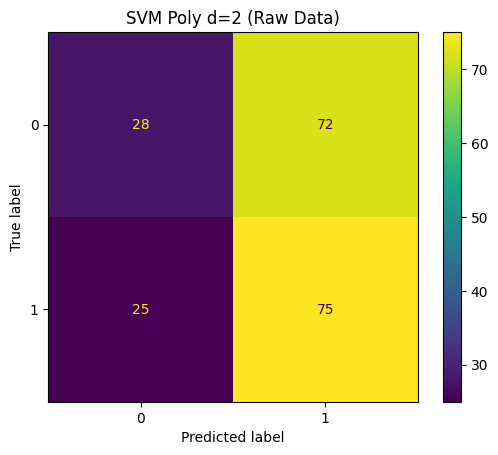

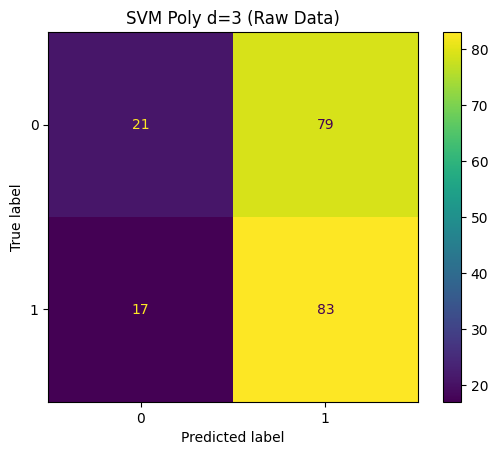

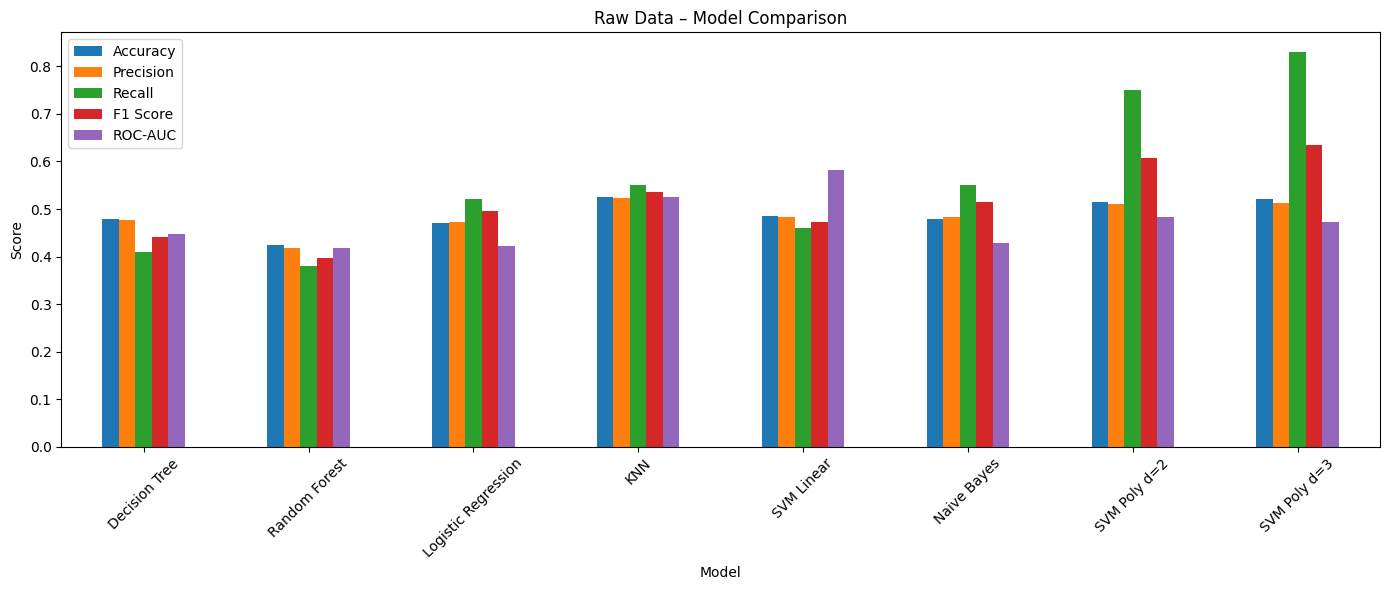

In [16]:
df_raw = pd.read_csv("D:/Machine Learning datasets/Classification/Student_Performance_Teaching_Effectiveness.csv")

df_raw["Performance"] = (df_raw["Final_Grade"] >= df_raw["Final_Grade"].median()).astype(int)
df_raw.drop(columns=["Final_Grade"], inplace=True)

Xr = df_raw.drop("Performance", axis=1)
yr = df_raw["Performance"]

for col in Xr.select_dtypes(include="object").columns:
    Xr[col] = LabelEncoder().fit_transform(Xr[col])

Xr_train, Xr_test, yr_train, yr_test = train_test_split(
    Xr, yr, test_size=0.2, random_state=42, stratify=yr
)

raw_results = []
for name, model in models.items():
    model.fit(Xr_train, yr_train)
    y_pred = model.predict(Xr_test)
    y_prob = model.predict_proba(Xr_test)[:, 1]

    raw_results.append({
        "Model": name,
        "Accuracy": accuracy_score(yr_test, y_pred),
        "Precision": precision_score(yr_test, y_pred),
        "Recall": recall_score(yr_test, y_pred),
        "F1 Score": f1_score(yr_test, y_pred),
        "ROC-AUC": roc_auc_score(yr_test, y_prob)
    })

    ConfusionMatrixDisplay.from_predictions(yr_test, y_pred)
    plt.title(f"{name} (Raw Data)")
    plt.show()

pd.DataFrame(raw_results).set_index("Model").plot(kind="bar", figsize=(14, 6))
plt.title("Raw Data – Model Comparison")
plt.ylabel("Score")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [17]:
joblib.dump(scaler, "scaler.pkl")
joblib.dump(df, "processed_student_data.pkl")

for name, model in models.items():
    joblib.dump(model, f"{name.replace(' ', '_')}.pkl")
